<a href="https://colab.research.google.com/github/nidhi-059/Deep-learning-projects/blob/main/Denoising_autoencoders.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch.utils.data
from torchvision import datasets, transforms
import numpy as np
import pandas as pd
from torch import nn, optim
device = 'cuda' if torch.cuda.is_available() else 'cpu'
from torch.optim import optimizer

In [ ]:
from torch.utils.data import DataLoader
transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize(0,1)])
mnist_dataset_train = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
mnist_dataset_test = datasets.MNIST(root='./data', train=False, download=True, transform=transform)
batch_size = 128
train_loader = torch.utils.data.DataLoader(mnist_dataset_train, batch_size = batch_size, shuffle=True)
test_loader = torch.utils.data.DataLoader(mnist_dataset_test, batch_size = 5, shuffle=False)

100%|██████████| 9.91M/9.91M [00:00<00:00, 138MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 9.86MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 116MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 10.3MB/s]


In [ ]:

class Denoising_auto(nn.Module):
  def __init__(self):
    super().__init__()

    self.conv1 = nn.Conv2d(1, 32, kernel_size=3,stride = 2, padding=1)
    self.conv2 = nn.Conv2d(32, 64, kernel_size=3,stride=2, padding=1)

    self.conv3 = nn.ConvTranspose2d(64, 32, kernel_size=3, stride=2, padding=1, output_padding=1)
    self.conv4 = nn.ConvTranspose2d(32,1, kernel_size=3, stride=2, padding=1, output_padding=1)

    self.relu = nn.ReLU()
    self.sigmoid = nn.Sigmoid()

  def encode(self, x):

    h1 = self.relu(self.conv1(x))
    return self.relu(self.conv2(h1))

  def decode(self, z):
    h3 = self.relu(self.conv3(z))
    return self.sigmoid(self.conv4(h3))

  def forward(self, x):
    q = self.encode(x)
    return self.decode(q)

model = Denoising_auto().to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-3)
loss_fn = nn.BCELoss()

epochs = 10

def train(epoch, model, train_loader, optimizer, cuda=True):
  model.train()
  train_loss = 0
  for batch_idx, (data, _) in enumerate(train_loader):
    data = data.to(device)
    optimizer.zero_grad()
    mean = 0.0
    std = 0.3
    noise = torch.randn_like(data) * std + mean
    noisy_data = data + noise
    noisy_data = torch.clamp(noisy_data, 0., 1.)

    output = model(noisy_data)

    loss = loss_fn(output, data)
    loss.backward()

    train_loss += loss.item() * data.size(0)
    optimizer.step()

  print(f"Epoch = {epoch+1}, Loss = {train_loss/len(train_loader.dataset)}")


for epoch in range(epochs):
  train(epoch, model, train_loader, optimizer)






Epoch = 1, Loss = 0.1381761887550354
Epoch = 2, Loss = 0.08034035959641139
Epoch = 3, Loss = 0.07938181178569793
Epoch = 4, Loss = 0.07882170441945394
Epoch = 5, Loss = 0.07842259466648102
Epoch = 6, Loss = 0.07813920973539352
Epoch = 7, Loss = 0.07789412828286489
Epoch = 8, Loss = 0.07769043764273326
Epoch = 9, Loss = 0.07754147386550904
Epoch = 10, Loss = 0.07741033051808675


In [ ]:
def evaluate(model, test_loader, loss_fn, device):
    model.eval()
    test_loss = 0

    with torch.no_grad():
        for data, _ in test_loader:
            data = data.to(device)


            noise = torch.randn_like(data) * 0.3
            noisy_data = torch.clamp(data + noise, 0., 1.)

            output = model(noisy_data)
            loss = loss_fn(output, data)

            test_loss += loss.item() * data.size(0)

    avg_loss = test_loss / len(test_loader.dataset)
    print(f"Test Loss: {avg_loss:.4f}")
    return avg_loss


In [ ]:
evaluate(model, test_loader, loss_fn, device)


Test Loss: 0.0769


0.07690136697515845

In [ ]:
import matplotlib.pyplot as plt

def visualize_denoising(model, data_loader, device, n=5):
    model.eval()

    data, _ = next(iter(data_loader))
    data = data.to(device)


    noise = torch.randn_like(data) * 0.3
    noisy_data = torch.clamp(data + noise, 0., 1.)

    with torch.no_grad():
        # model(noisy_data) returns (Batch, 1, 28, 28)
        recon = model(noisy_data)

    # Moving to CPU for plotting
    data = data.cpu()
    noisy_data = noisy_data.cpu()
    recon = recon.cpu()

    plt.figure(figsize=(15, 6))
    for i in range(n):
        # Original
        ax = plt.subplot(3, n, i + 1)
        plt.imshow(data[i].squeeze(), cmap='gray')
        plt.title("Original")
        ax.axis('off')

        # Noisy
        ax = plt.subplot(3, n, i + 1 + n)
        plt.imshow(noisy_data[i].squeeze(), cmap='gray')
        plt.title("Noisy")
        ax.axis('off')

        # Reconstruction
        ax = plt.subplot(3, n, i + 1 + 2 * n)
        plt.imshow(recon[i].squeeze(), cmap='gray')
        plt.title("Denoised")
        ax.axis('off')

    plt.tight_layout()
    plt.show()


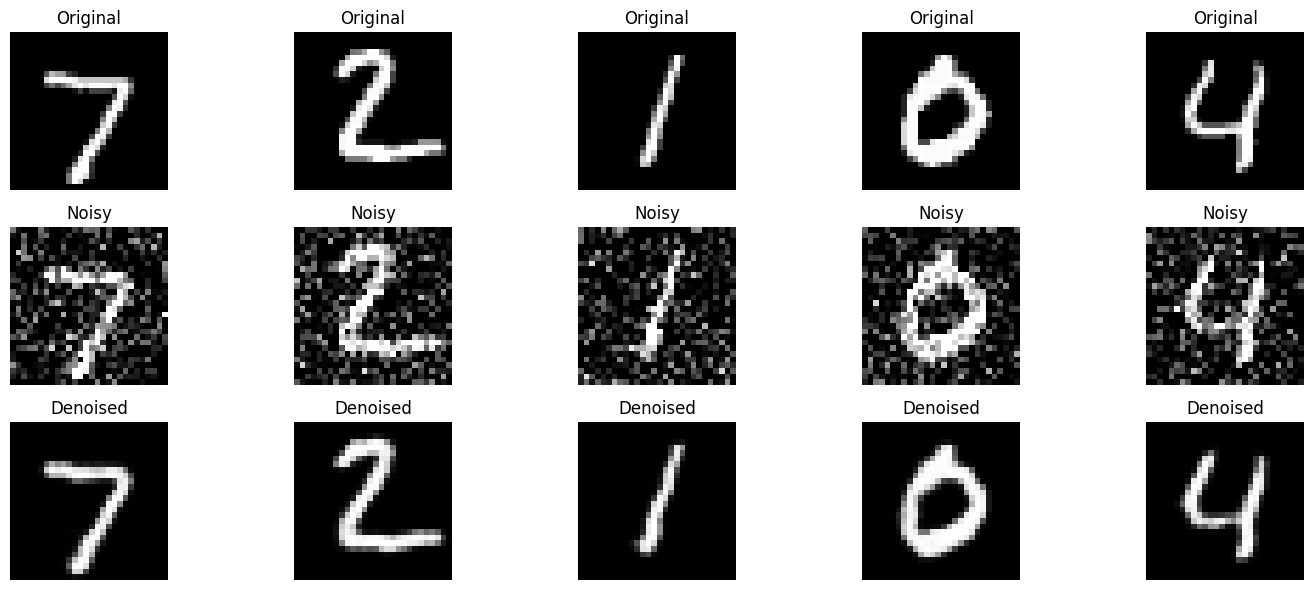

In [ ]:
visualize_denoising(model, test_loader, device)